<a href="https://colab.research.google.com/github/Sofiosu24/IA_training_classification_realWaste/blob/Fase2_1_Revision_modelo/RealWaste_UseModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os

base_dir = '/content/drive/MyDrive/realwaste_main/RealWaste'
test_dir = os.path.join(base_dir, 'test')

print("Test:", test_dir)

Test: /content/drive/MyDrive/realwaste_main/RealWaste/test


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model = load_model('/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v3.keras')

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='categorical',
    shuffle=False)

class_names = list(test_generator.class_indices.keys())

Found 714 images belonging to 9 classes.


In [8]:
import random, os
from tensorflow.keras.preprocessing import image
import numpy as np

# Elegir una clase y una imagen al azar de la carpeta de test
clase = random.choice(class_names)
carpeta = os.path.join(test_dir, clase)
nombre_archivo = random.choice(os.listdir(carpeta))
ruta = os.path.join(carpeta, nombre_archivo)

# Cargar y preprocesar
img = image.load_img(ruta, target_size=(150, 150))
img_array = image.img_to_array(img) / 255
img_batch = np.expand_dims(img_array, axis=0)

# Predecir
predictions_single = model.predict(img_batch, verbose=0)
predicted_label = np.argmax(predictions_single[0])

# La etiqueta real es el nombre de la carpeta
true_label = class_names.index(clase)

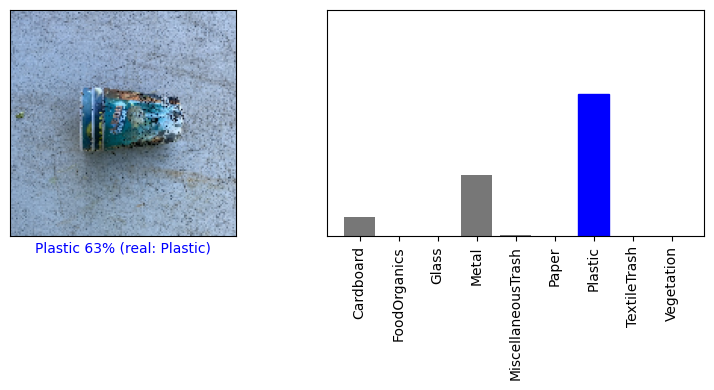

In [9]:
# Mostrar imagen y gráfica de predicción de barras
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.xticks([]); plt.yticks([]); plt.grid(False)
color = 'blue' if predicted_label == true_label else 'red'
plt.xlabel("{} {:2.0f}% (real: {})".format(
    class_names[predicted_label],
    100 * np.max(predictions_single[0]),
    class_names[true_label]), color=color)

plt.subplot(1, 2, 2)
plt.grid(False)
plt.xticks(range(9), class_names, rotation=90)
plt.yticks([])
barras = plt.bar(range(9), predictions_single[0], color="#777777")
plt.ylim([0, 1])
barras[predicted_label].set_color('red')
barras[true_label].set_color('blue')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

subido = files.upload()

Saving 942030.jpeg to 942030.jpeg


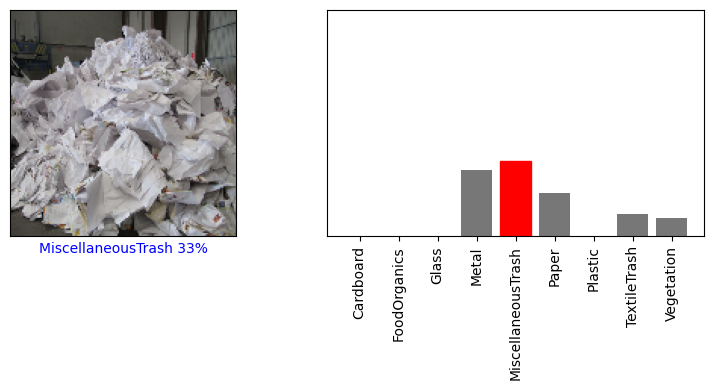

In [ ]:
for nombre in subido.keys():
    # Cargar y preprocesar
    img = image.load_img(nombre, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Predecir
    predictions_single = model.predict(img_batch, verbose=0)
    predicted_label = np.argmax(predictions_single[0])

    # Mostrar imagen y gráfica de predicción de barras
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_array)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.xlabel("{} {:2.0f}%".format(
        class_names[predicted_label],
        100 * np.max(predictions_single[0])), color='blue')

    plt.subplot(1, 2, 2)
    plt.grid(False)
    plt.xticks(range(9), class_names, rotation=90)
    plt.yticks([])
    barras = plt.bar(range(9), predictions_single[0], color="#777777")
    plt.ylim([0, 1])
    barras[predicted_label].set_color('red')

    plt.tight_layout()
    plt.show()